#### Note: This solution is for my personal practice reasons only

In [1]:
import numpy as np # for mathematical operations
import pandas as pd # for data processing and analysis
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for data visualization
from sklearn.preprocessing import StandardScaler # for data preprocessing
from sklearn.linear_model import LinearRegression # for linear regression model
from sklearn.ensemble import RandomForestRegressor # for random forest regression model
from xgboost import XGBRFRegressor # for XGBoost regression model
from sklearn.feature_selection import RFE # for Recursive Feature Elimination
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # for regression evaluation metrics
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV # for model selection and evaluation

import warnings # to ignore warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')
Id = test_df['Id']

In [3]:
train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
train_df.shape

(1460, 81)

In [6]:
test_df.shape

(1459, 80)

In [7]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
train_df.select_dtypes(include=['int64', 'float64']).head() #Printing all the numerical columns

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


In [9]:
train_df.select_dtypes(include=['object']).head() #Printing all the categorical columns

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


### Dealing with missing values:

In [10]:
train_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

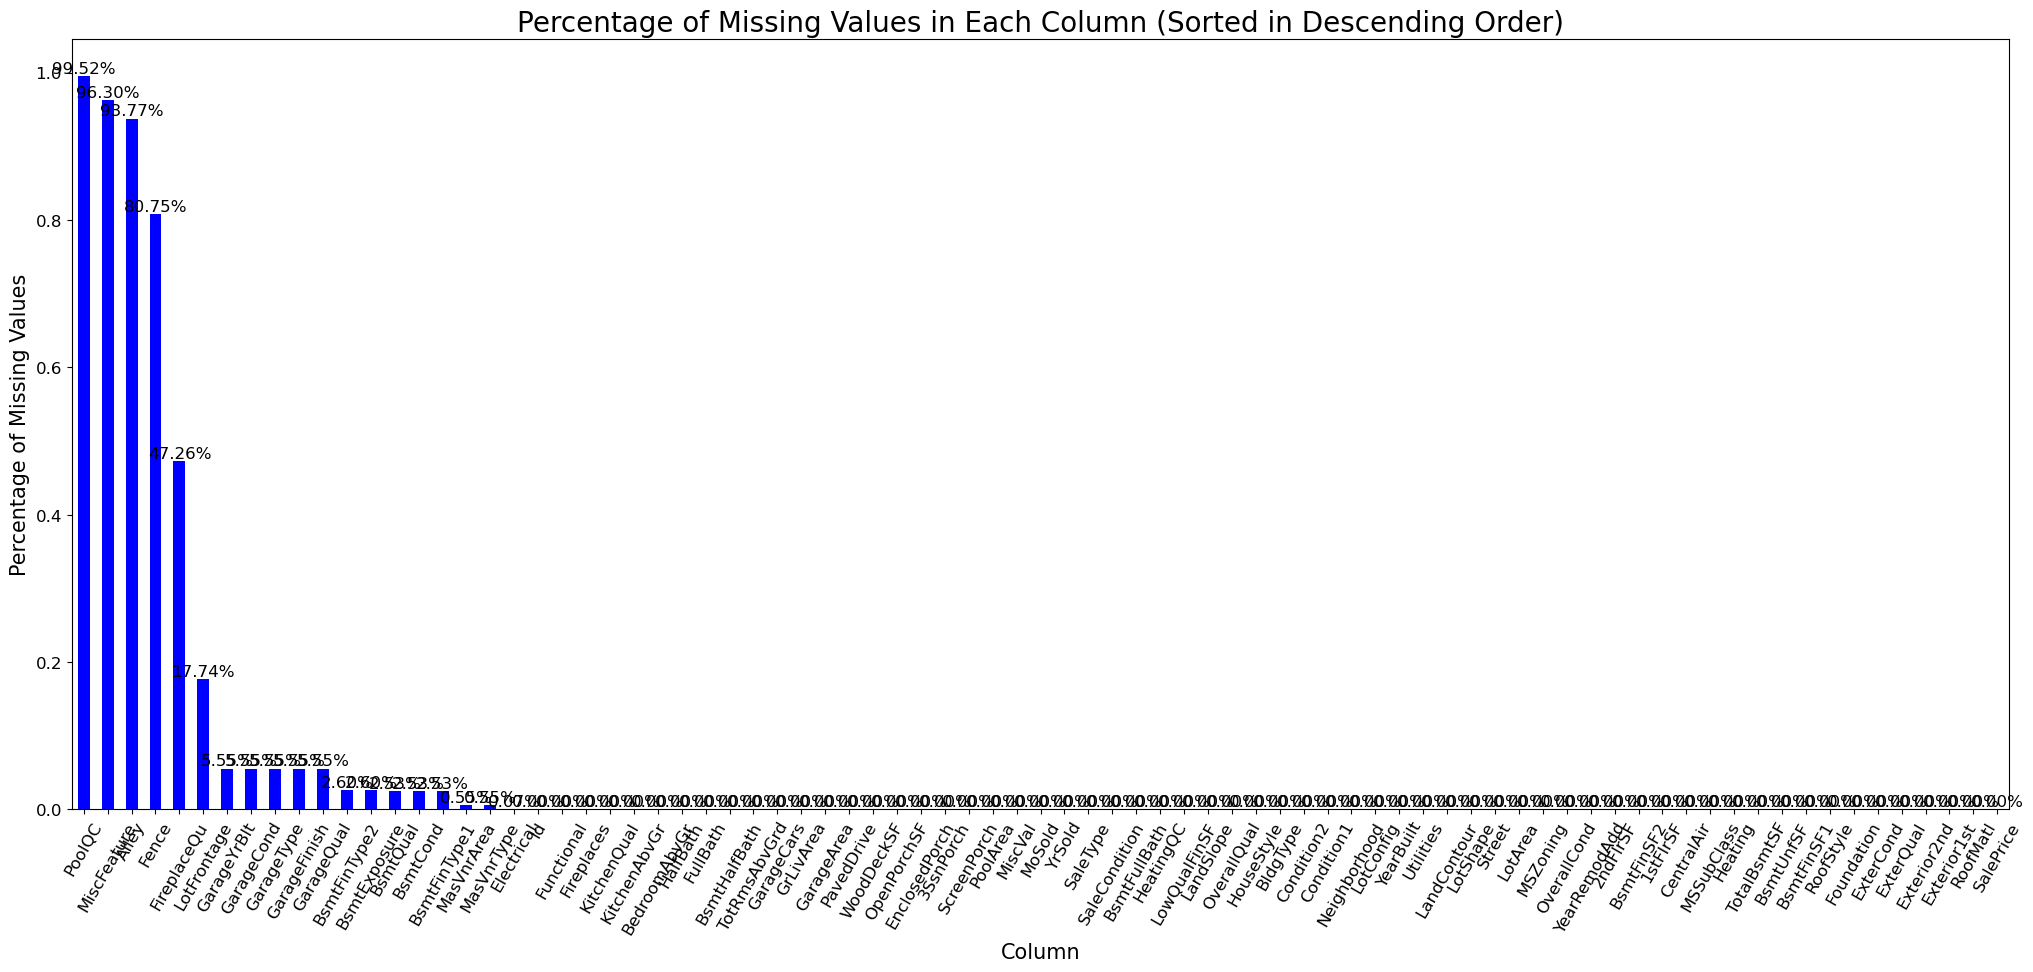

In [11]:
# Plotting to see all the null values in the data set 
def plot_missing_values_bar(df):
    plt.figure(figsize=(25, 10))
    missing_values = df.isnull().mean().sort_values(ascending=False)
    missing_values.plot(kind='bar', color='blue')
    plt.title("Percentage of Missing Values in Each Column (Sorted in Descending Order)", fontsize=20)
    plt.xlabel("Column", fontsize=15)
    plt.ylabel("Percentage of Missing Values", fontsize=15)
    plt.xticks(rotation=60, fontsize=12)
    plt.yticks(fontsize=12)

    for i in range(df.shape[1]):
        plt.text(x=i, y=missing_values[i], s='{:.2f}%'.format(100*missing_values[i]), ha='center', va='bottom', fontsize=12)
    
plot_missing_values_bar(train_df) #plotting

In [12]:
pd.set_option('display.max_rows', train_df.shape[0])
pd.DataFrame(train_df.isnull().sum().sort_values(ascending = False))

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
FireplaceQu,690
LotFrontage,259
GarageYrBlt,81
GarageCond,81
GarageType,81
GarageFinish,81


In [13]:
null_percent = train_df.isnull().sum() / train_df.shape[0] *100   #Gettign the all the null vlaues percentage
cols_to_drop = null_percent[null_percent > 50 ].keys()  #Collumns to drop which null values more than 50% 
cols_to_drop  

Index(['Alley', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [14]:
train_df.drop(columns=['Alley', 'PoolQC', 'Fence', 'MiscFeature'], inplace=True) #dropping the columns which have more than 50 % null values

In [15]:
# Checking the remaining columns with null values 
print(f'1) Columns with missing values:- \n ',train_df.columns[train_df.isnull().any()], '\n')          #Printing all the remaining columns with null values 
print(f'2) Total number of columns with missing values: ',len((train_df.columns[train_df.isnull().any()])))   #Printing number of all the remainig columns with null values

1) Columns with missing values:- 
  Index(['LotFrontage', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageQual', 'GarageCond'],
      dtype='object') 

2) Total number of columns with missing values:  15


In [16]:
## Replacing the null values of numerical columns with mean 
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].mean())   #Replacing the null values of 'LotFrontage' with mean 
train_df['MasVnrArea']  = train_df['MasVnrArea'].fillna(train_df['MasVnrArea'].mean())     #Replacing the null values of 'MasVnrArea' with mean
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(train_df['GarageYrBlt'].mean())   #Replacing the null values of 'GarageYrBlt' with mean

# Checking the remaining columns with null values 
print(f'1) Remaining Columns with missing values:- \n ',train_df.columns[train_df.isnull().any()], '\n')          #Printing all the remaining columns with null values 
print(f'2) Remaining Total number of columns with missing values: ',len((train_df.columns[train_df.isnull().any()])))   #Printing number of all the remainig columns with null values

1) Remaining Columns with missing values:- 
  Index(['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond'],
      dtype='object') 

2) Remaining Total number of columns with missing values:  12


In [17]:
# Replacing all the null values of the categorical columns with the first mode 
train_df['MasVnrType']   = train_df['MasVnrType'].fillna(train_df['MasVnrType'].mode()[0])  
train_df['BsmtQual']     = train_df['BsmtQual'].fillna(train_df['BsmtQual'].mode()[0])  
train_df['BsmtCond']     = train_df['BsmtCond'].fillna(train_df['BsmtCond'].mode()[0])  
train_df['BsmtExposure'] = train_df['BsmtExposure'].fillna(train_df['BsmtExposure'].mode()[0])  
train_df['BsmtFinType1'] = train_df['BsmtFinType1'].fillna(train_df['BsmtFinType1'].mode()[0])  
train_df['BsmtFinType2'] = train_df['BsmtFinType2'].fillna(train_df['BsmtFinType2'].mode()[0])  
train_df['Electrical']   = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])  
train_df['FireplaceQu']  = train_df['FireplaceQu'].fillna(train_df['FireplaceQu'].mode()[0])  
train_df['GarageType']   = train_df['GarageType'].fillna(train_df['GarageType'].mode()[0])  
train_df['GarageFinish'] = train_df['GarageFinish'].fillna(train_df['GarageFinish'].mode()[0])  
train_df['GarageQual']   = train_df['GarageQual'].fillna(train_df['GarageQual'].mode()[0])  
train_df['GarageCond']   = train_df['GarageCond'].fillna(train_df['GarageCond'].mode()[0])  


In [18]:
# Checking the remaining columns with null values 
print(f' Total missing values: ',train_df.isnull().values.sum())   

 Total missing values:  0


### Finding most important features:

In [19]:
# Finding the highly corrolated columns
corr = train_df.corr()

high_corr_features = corr.index[abs(corr['SalePrice']) > 0.5] 
print(f'Highly Corrolated Features:\n', high_corr_features, '\n') #Printing the features which are highly corrolated or are more than '0.5'
print(f'No. of Highly Corrolated Features:', len(high_corr_features))

Highly Corrolated Features:
 Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea',
       'SalePrice'],
      dtype='object') 

No. of Highly Corrolated Features: 11


Text(145.72222222222223, 0.5, 'Features')

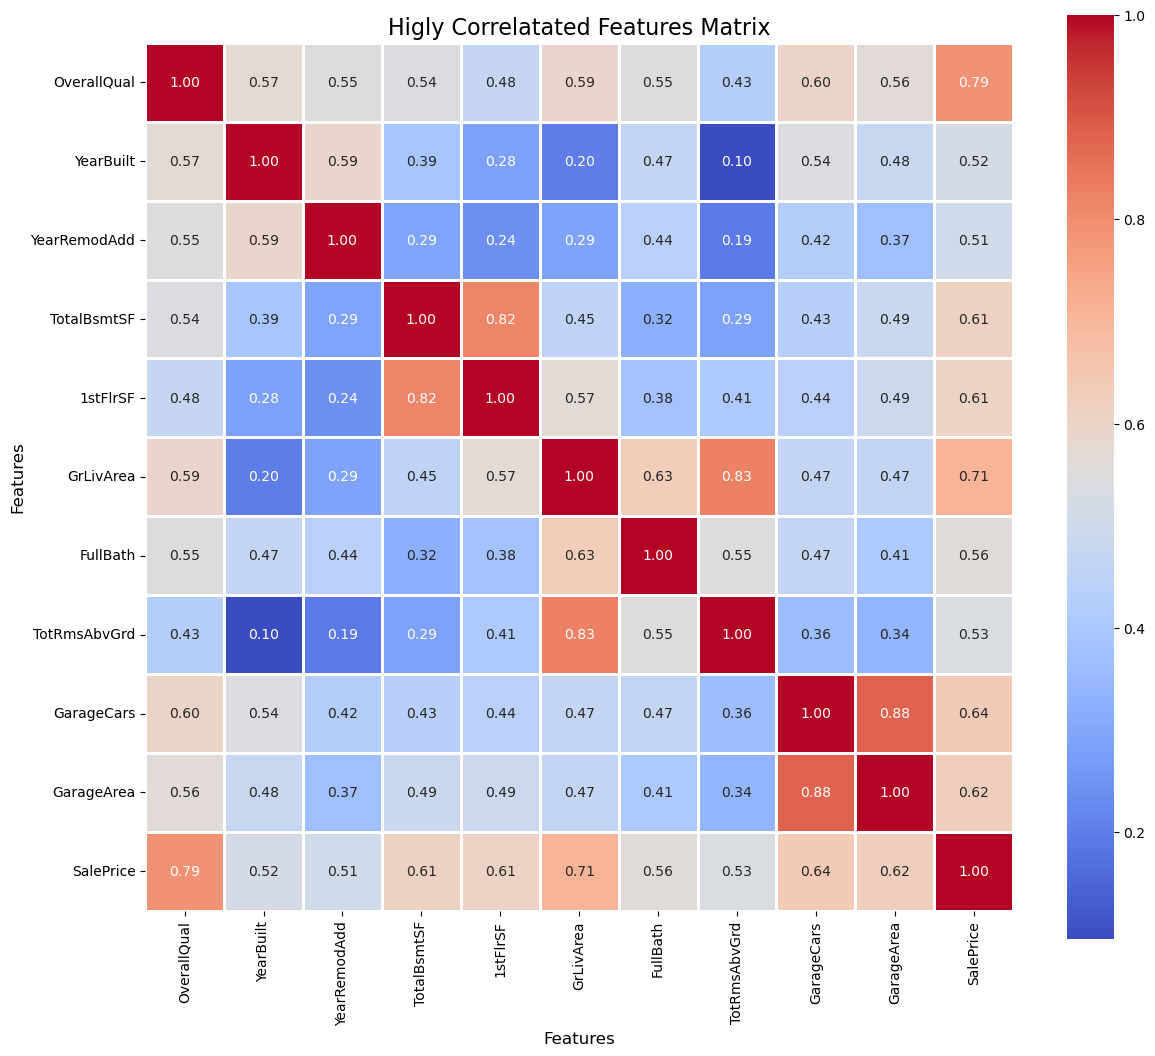

In [20]:
#Ploting the heatmap of only the highly corrolated features
plt.figure(figsize=(14,12))   
sns.heatmap(train_df[high_corr_features].corr(), annot=True, cmap='coolwarm', cbar=True, fmt='.2f', square=True, linewidths=2)

# Adding title and labels to the plot
plt.title('Higly Correlatated Features Matrix', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)

### One hot encoding:

In [21]:
train = pd.get_dummies(train_df, drop_first=True)  #One HOt Encoding all the catigorical columns for train data set
test = pd.get_dummies(test_df, drop_first=True)  #One HOt Encoding all the catigorical columns for test data set
print(train.shape)   #checking if columns and rows if it has incresased after one hot encoding
print(test.shape)  #checking if columns and rows if it has incresased after one hot encoding

(1460, 238)
(1459, 228)


In [22]:
print(f'No of Catigorical Columns in train dataset: ', len(train.select_dtypes(include='object').columns))   #checking if any catigorical colummn is left after one hot encoding 
print(f'No of Catigorical Columns in test dataset: ', len(test.select_dtypes(include='object').columns))   #checking if any catigorical colummn is left after one hot encoding 

No of Catigorical Columns in train dataset:  0
No of Catigorical Columns in test dataset:  0


In [23]:
X = train[high_corr_features.drop('SalePrice')]      #Droping the target variable from the train dataset and selecting the highly corrolated variable
y = train[['SalePrice']]                               #Target Variable of the train dataset


test = test[high_corr_features.drop('SalePrice')]      #selecting te same features for the the test dataset also

# Slpitting the dataset into train  & Test
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

# Checking if the data is splitted properly
print(f'X_train',X_train.shape)  #Printing the X_train Features Shape
print(f'y_train',y_train.shape)  #Printing the y_train Labels Shape
print(f'X_val',X_val.shape)    #Printing the X_test Features Shape
print(f'y_val',y_val.shape)    #Printing the y_test Labels  Shape

X_train (1168, 10)
y_train (1168, 1)
X_val (292, 10)
y_val (292, 1)


### Scaling data:

In [24]:
# Droping nan values form the test dataset
test.fillna(test.mode().iloc[0], inplace=True) 

# Normalizing the data 
ss = StandardScaler()
X_train = ss.fit_transform(X_train)  #fit and transforming the train from train dataset
X_val = ss.transform(X_val)        #transforming the validation teat from train dataset

test = ss.transform(test)           #transforming the test dataset

### Building model:

In [25]:
# Model Building
xgbr = XGBRFRegressor(random_state=0) #Creating the XGBoost Regressor Model
xgbr.fit(X_train, y_train)            #Training the Model with X_train & y_train
pred = xgbr.predict(X_val)           #Predicting the X_test 

#Testing the model accuracy with different paramtes
r2   = r2_score(y_val, pred)             # Getting the R-squared (R²)
mae  = mean_absolute_error(y_val, pred)  # Getting the Mean Absolute Error
mse  = mean_squared_error(y_val, pred)   # Getting the Mean Squared Error
rmse = np.sqrt(mse)                       # Getting the Root Mean Squared Error

In [26]:
print(r2)
print(mae)
print(mse)
print(rmse)

0.8389402497452858
20293.735846532534
1112254470.498941
33350.47931438079


In [27]:
pred = xgbr.predict(test)

In [28]:
new_test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')  #importing again the test dataset for attaching the id 
output = pd.DataFrame({'Id': Id, 'SalePrice': pred.flatten()})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
